# Few-shot vein segmentation of *Populus trichocarpa* leaves — single-example reproduction

**Paper:** Lagergren et al., *Few-Shot Learning Enables Population-Scale Analysis of Leaf Traits in Populus trichocarpa*, Plant Phenomics 5:0072 (2023). DOI: [10.34133/plantphenomics.0072](https://doi.org/10.34133/plantphenomics.0072) (open access: PMCID PMC10380552, CC BY 4.0)

**Author code:** [`jlager/few-shot-leaf-segmentation`](https://github.com/jlager/few-shot-leaf-segmentation) @ commit `3c8c4acdc16b2442fd9c5932e04e4730751f70e3` (GPL-3.0). The CNN architecture and region-growing algorithm below are the authors' own files, fetched unmodified at runtime from the pinned commit and verified by git blob SHA-1.

**What this notebook does (scope):** loads the authors' released **vein-growing CNN with Focal Loss weights** and runs their exact inference path (`notebooks/GrowerInference.ipynb` → `models/VeinGrower.py`) on **one** released leaf-bottom scan, `C_1_14_18_bot.jpeg` — a held-out **validation** image of the vein model (`notebooks/GrowerTraining.ipynb`, `val_img_idx`). It reproduces the vein probability map and segmentation mask, then compares them with (1) the authors' released prediction `data/vein_fl_preds/C_1_14_18_bot.png` and (2) the manual ground-truth mask `data/vein_masks/C_1_14_18_bot.png` (Jaccard index).

**What is NOT done here:** training any model, U-Net baselines, the leaf tracer, trait extraction (Fiji / RhizoVision Explorer), TPS/BLUP correction, GWAS, or the population-scale run over all 1,453 bottom scans. A single-example run is **not** a verification of the paper's dataset-level metrics.

**Runtime:** select **Runtime → Change runtime type → T4 GPU** (recommended/validated). The same code also runs on CPU (the authors' code falls back to CPU) but is much slower and was not validated for timing.

**ダウンロード / 実行時間の目安:** 約4 MBのダウンロード、T4 GPUで概ね数分。CPUでも動作しますが大幅に遅くなります。

**日本語要約:** このノートブックは、著者公開の「静脈成長CNN(Focal Loss重み)」を検証用葉裏スキャン1枚に実行し、静脈確率マップとセグメンテーションを再現します。著者の公開予測および手作業の正解マスクとJaccard指数で比較します。学習・U-Net・形質抽出・GWASは対象外です。

## 1. Environment and device check

**EN:** Verifies the Colab runtime and selects the torch device. The authors' helper `utils/GetLowestGPU.py` parses `nvidia-smi` to pick the least-loaded GPU; on a single-GPU Colab VM we simply use CUDA when available (documented adaptation #1).

**JP:** ランタイムのtorch/CUDAを確認し、デバイスを選択します。著者の `GetLowestGPU.py` の代わりに、Colabの単一GPU構成に合わせ `torch.cuda.is_available()` を使用します。

In [ ]:
import os, sys, glob, time, json, hashlib, urllib.request
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch
from PIL import Image
import pandas as pd

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('torch       :', torch.__version__)
print('CUDA avail. :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU         :', torch.cuda.get_device_name(0))
print('device      :', device)
print('numpy       :', np.__version__)
import scipy
print('scipy       :', scipy.__version__)

torch       : 2.11.0+cu130
CUDA avail. : True
GPU         : Tesla T4
device      : cuda
numpy       : 2.1.3
scipy       : 1.16.3


## 2. Fetch the pinned author files (code, weights, one sample)

**EN:** Downloads 7 files from the pinned author commit `3c8c4ac…` on `raw.githubusercontent.com` and verifies each one against its **git blob SHA-1** (`sha1("blob <size>\0" + bytes)`) and byte count recorded from the GitHub tree API. The 2.5 MB Focal-Loss checkpoint, the two model definitions, and four image products for the validation sample `C_1_14_18_bot` total ≈ 3.9 MB. Nothing else from the 6 GB dataset is downloaded.

**JP:** 著者リポジトリの固定コミットから、モデル定義2種・FL重み・検証用サンプル画像・葉ROI・正解マスク・著者公開予測の計7ファイル(約3.9 MB)を取得し、git blob SHA-1で完全性を検証します。

In [ ]:
COMMIT = '3c8c4acdc16b2442fd9c5932e04e4730751f70e3'
BASE = f'https://raw.githubusercontent.com/jlager/few-shot-leaf-segmentation/{COMMIT}'
# relative path in repo -> (git blob SHA-1, expected size in bytes)
FILES = {
    'models/BuildCNN.py':                            ('eb95f41749ffdc480d722a0073e34c24fc8c161a',    8404),
    'models/VeinGrower.py':                          ('ca03a6adcdfaaddb9a6afeaab6cf68d98fd6cd35',    7815),
    'weights/vein_grower_fl_128_best_val_model.save':('10b29b02cb31ed57fe491960731ccf11974c6a1d', 2459713),
    'data/images/C_1_14_18_bot.jpeg':                ('51973a451e905b445629fe8c45bcf1011e11a633', 1004265),
    'data/leaf_preds/C_1_14_18_bot.png':             ('74e6a0908c84866a8510dcffc4985a5977134879',   38645),
    'data/vein_masks/C_1_14_18_bot.png':             ('39bf0c3d559d36d30a14dd867ee335e0ae6b7102',  197302),
    'data/vein_fl_preds/C_1_14_18_bot.png':          ('d91e82d669d3e68b31f9cc535562596dd260e9b9',  180947),
}
ROOT = Path('/content/few_shot_leaf')
for rel, (blob_sha, size) in FILES.items():
    dest = ROOT / rel
    dest.parent.mkdir(parents=True, exist_ok=True)
    if not dest.exists():
        urllib.request.urlretrieve(f'{BASE}/{rel}', dest)  # pinned raw URL
    data = dest.read_bytes()
    got = hashlib.sha1(b'blob %d\x00' % len(data) + data).hexdigest()
    assert len(data) == size, f'{rel}: expected {size} bytes, got {len(data)}'
    assert got == blob_sha, f'{rel}: blob SHA-1 mismatch ({got})'
    print(f'OK  {rel:52s} {len(data):>8d} B  blob sha1 verified')

IMG_PATH    = ROOT / 'data/images/C_1_14_18_bot.jpeg'
ROI_PATH    = ROOT / 'data/leaf_preds/C_1_14_18_bot.png'
GT_PATH     = ROOT / 'data/vein_masks/C_1_14_18_bot.png'
AUTHOR_PATH = ROOT / 'data/vein_fl_preds/C_1_14_18_bot.png'
WEIGHTS_PATH= ROOT / 'weights/vein_grower_fl_128_best_val_model.save'

OK  models/BuildCNN.py                                       8404 B  blob sha1 verified
OK  models/VeinGrower.py                                     7815 B  blob sha1 verified


OK  weights/vein_grower_fl_128_best_val_model.save        2459713 B  blob sha1 verified


OK  data/images/C_1_14_18_bot.jpeg                        1004265 B  blob sha1 verified
OK  data/leaf_preds/C_1_14_18_bot.png                       38645 B  blob sha1 verified


OK  data/vein_masks/C_1_14_18_bot.png                      197302 B  blob sha1 verified
OK  data/vein_fl_preds/C_1_14_18_bot.png                   180947 B  blob sha1 verified


## 3. Input preview — the actual sample and its reference annotations

**EN:** Shows the real sample used by this reproduction before any computation: the leaf-bottom scan, the authors' released leaf-ROI mask (input to the grower: seeds are sampled only inside it), the manual ground-truth venation, and the authors' released vein-grower (FL) prediction. All four are byte-verified downloads from the pinned commit.

**JP:** ここで使用する実際のサンプル(葉裏スキャン)、著者の葉ROIマスク、手作業の正解静脈マスク、著者公開予測を、計算前に表示します。

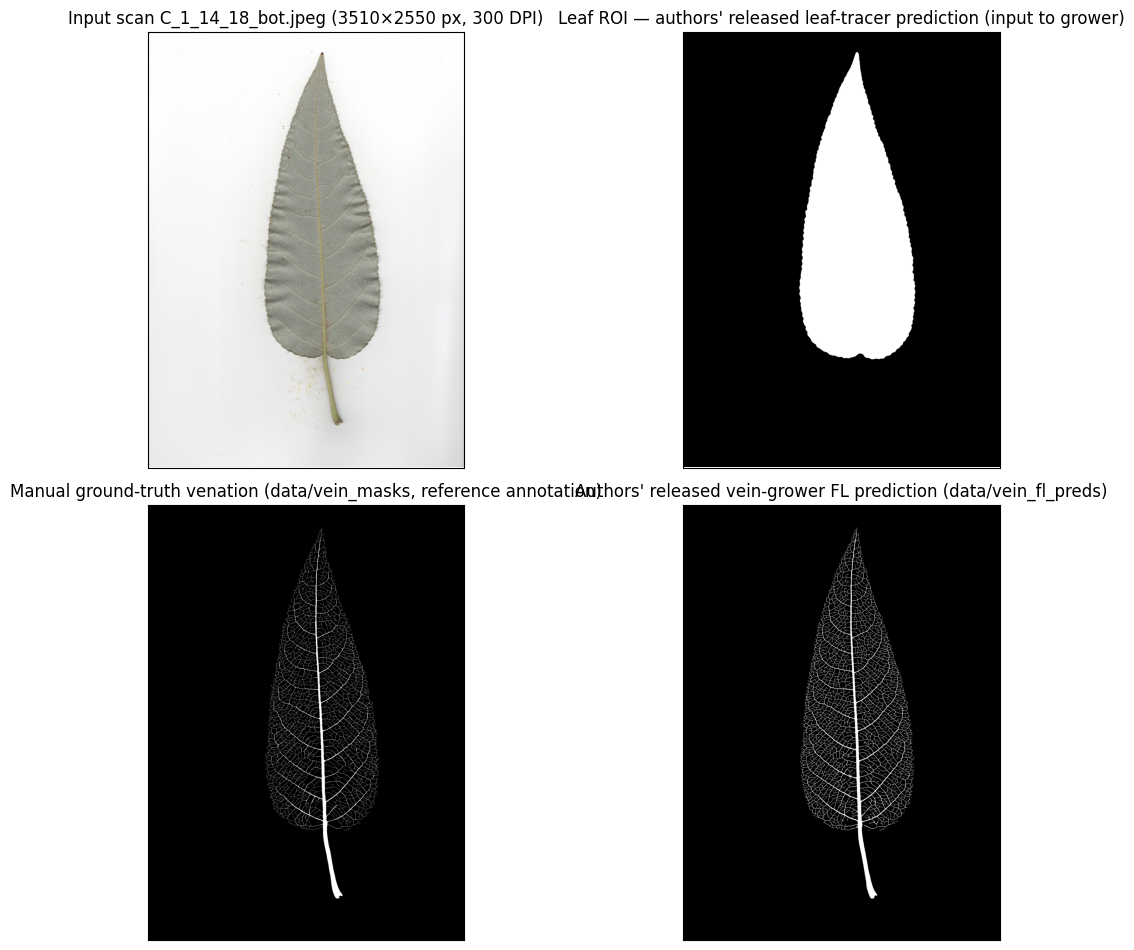

image: (3510, 2550, 3)  roi px: 1531690  gt vein px: 190167  author pred px: 270948


In [ ]:
image = np.array(Image.open(IMG_PATH), dtype=np.float32) / 255.0          # H,W,C in [0,1]
roi_png = np.array(Image.open(ROI_PATH), dtype=np.float32) / 255.0
roi = roi_png[:, :, 0] > 0.5                                              # author inference convention
def load_mask(path):                                                      # robust 2D/3D binary mask loader
    a = np.array(Image.open(path).convert('L'))
    return a > 127
gt_mask     = load_mask(GT_PATH)                                          # manual ground truth (venation)
author_mask = load_mask(AUTHOR_PATH)                                      # authors' released FL prediction

fig, axes = plt.subplots(2, 2, figsize=(13, 9.6))
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].imshow(image);                axes[0, 0].set_title('Input scan C_1_14_18_bot.jpeg (3510×2550 px, 300 DPI)')
axes[0, 1].imshow(roi, cmap='gray');     axes[0, 1].set_title("Leaf ROI — authors' released leaf-tracer prediction (input to grower)")
axes[1, 0].imshow(gt_mask, cmap='gray'); axes[1, 0].set_title('Manual ground-truth venation (data/vein_masks, reference annotation)')
axes[1, 1].imshow(author_mask, cmap='gray'); axes[1, 1].set_title("Authors' released vein-grower FL prediction (data/vein_fl_preds)")
plt.tight_layout(); plt.show()
print('image:', image.shape, ' roi px:', int(roi.sum()),
      ' gt vein px:', int(gt_mask.sum()), ' author pred px:', int(author_mask.sum()))

## 4. Build the CNN and load the released Focal-Loss weights

**EN:** Instantiates the authors' `models/BuildCNN.py` CNN exactly as in `GrowerInference.ipynb` — `window_size=128`, `layers=[3,32,32,32,32,64,128]`, `output_shape=[2,3,3]`, `Softmax2d` — and loads `vein_grower_fl_128_best_val_model.save` (the checkpoint from the epoch with the best validation error; Focal Loss variant). The only adaptation (#3) is the `weights_only` fallback for torch ≥ 2.6; strict `load_state_dict` must succeed with no missing/unexpected keys.

**JP:** 著者の `BuildCNN.CNN` を推論ノートブックと同一の構成で初期化し、FL重みチェックポイントを `load_state_dict`(strict)で読み込みます。torch 2.6以降の `weights_only` 引数への対応のみ追加しています。

In [ ]:
sys.path.insert(0, str(ROOT))                                             # author files live under /content/few_shot_leaf
import models.BuildCNN as BuildCNN
import models.VeinGrower as VeinGrower

window_size      = 128
layers           = [3, 32, 32, 32, 32, 64, 128]   # GrowerInference.ipynb, cell 2
output_shape     = [2, 3, 3]
output_activation = torch.nn.Softmax2d()

model = BuildCNN.CNN(
    window_size=window_size,
    layers=layers,
    output_shape=output_shape,
    output_activation=output_activation,
).to(device)
try:                                                                      # adaptation: torch>=2.6 defaults weights_only=True
    weights = torch.load(WEIGHTS_PATH, map_location=device, weights_only=True)
except TypeError:
    weights = torch.load(WEIGHTS_PATH, map_location=device)
model.load_state_dict(weights)                                            # strict: all keys must match
model.eval()
n_params = sum(p.numel() for p in model.parameters())
print(f'checkpoint tensors: {len(weights)} | parameters: {n_params:,} | state_dict loaded strictly, model in eval mode')

checkpoint tensors: 128 | parameters: 602,802 | state_dict loaded strictly, model in eval mode


## 5. Run the vein-growing CNN on the validation scan

**EN:** Executes the authors' `VeinGrower.grow()` unchanged, with the exact options from `GrowerInference.ipynb`: `n_locs=10000` seed pixels drawn from the leaf ROI, `batch_size=2048`, automatic probability thresholding (peak of −n_objects/size over 101 thresholds) and petiole post-processing. The only behavioral addition is `np.random.seed(0)` (adaptation #2): the author code leaves the seed-pixel choice unseeded, so this makes the run reproducible — masks may differ marginally between seeds, as in the original.

**JP:** 著者の `VeinGrower.grow()` を推論ノートブックと同一のオプションで実行します(シード画素10,000、バッチ2,048、自動しきい値、葉柄後処理)。再現性のため乱数シードのみ固定します(著者コードは未固定)。

In [ ]:
np.random.seed(0)                                                         # adaptation #2: reproducible seed-pixel choice
grower = VeinGrower.VeinGrower(window_size=window_size, model=model, device=device, verbose=True)

t0 = time.time()
prob, mask = grower.grow(
    image=image,            # H,W,C float in [0,1] (author inference convention)
    roi=roi,                # seed pixels are sampled inside the leaf ROI
    start_locs=None,
    n_locs=10000,
    batch_size=2048,
    threshold=None,         # automatic threshold search inside grow()
    post_process=True,      # keep largest outside-ROI object (petiole)
)
elapsed = time.time() - t0
prob = prob[0]              # foreground-channel probability map, (H, W)
print(f'\nvein grower finished in {elapsed:.1f} s on {device}')
print('probability map:', prob.shape, f'range [{prob.min():.3f}, {prob.max():.3f}]')
print(f'predicted vein pixels: {int(mask.sum()):,} '
      f'({mask.mean()*100:.2f}% of image)')

Iteration 0 | Samples = 10000           

Iteration 1 | Samples = 12407           

Iteration 2 | Samples = 17693           

Iteration 3 | Samples = 18730           

Iteration 4 | Samples = 18032           

...

Iteration 573 | Samples = 23           

Iteration 576 | Samples = 0           


Computing optimal threshold...


Post processing...

vein grower finished in 359.7 s on cuda
probability map: (3510, 2550) range [0.000, 1.000]


predicted vein pixels: 264,803 (2.96% of image)


## 6. Results — reproduced prediction vs. authors' released prediction vs. ground truth

**EN:** Overlays the reproduced mask on the input scan (red), shows the predicted foreground probability map, and compares the authors' released prediction and the manual ground truth with the same overlay convention. Reference annotations and model predictions are labeled separately.

**JP:** 再現した予測マスクを赤で入力画像に重ねて表示し、確率マップ・著者公開予測・正解マスクを並べて比較します。

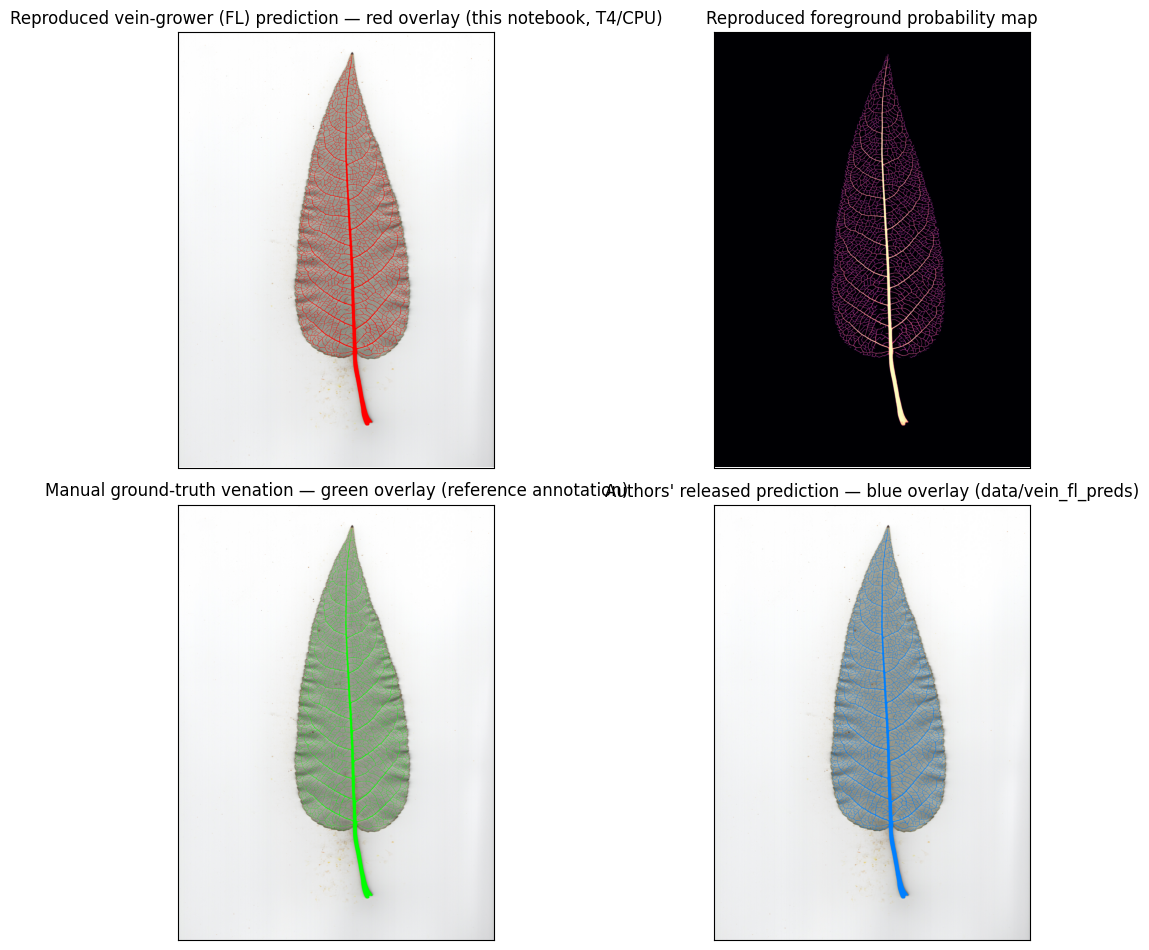

In [ ]:
overlay = image.copy()
overlay[mask] = [1, 0, 0]                                                 # author overlay convention: predicted veins in red
gt_overlay = image.copy();      gt_overlay[gt_mask] = [0, 1, 0]           # ground truth in green
author_overlay = image.copy();  author_overlay[author_mask] = [0, 0.5, 1] # authors' released prediction in blue

fig, axes = plt.subplots(2, 2, figsize=(13, 9.6))
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].imshow(overlay);        axes[0, 0].set_title('Reproduced vein-grower (FL) prediction — red overlay (this notebook, T4/CPU)')
axes[0, 1].imshow(prob, cmap='magma', vmin=0, vmax=1); axes[0, 1].set_title('Reproduced foreground probability map')
axes[1, 0].imshow(gt_overlay);     axes[1, 0].set_title('Manual ground-truth venation — green overlay (reference annotation)')
axes[1, 1].imshow(author_overlay); axes[1, 1].set_title("Authors' released prediction — blue overlay (data/vein_fl_preds)")
plt.tight_layout(); plt.show()

## 7. Quantitative comparison (Jaccard index)

**EN:** Computes the Jaccard index of (a) the reproduced mask vs. the manual ground truth, (b) the authors' released prediction vs. the ground truth, and (c) the reproduced mask vs. the authors' released prediction. The paper reports vein-grower (FL) validation Jaccard ≈ 0.6586/0.6381 for its two held-out images (which value belongs to which image is not stated in the sources used here), so (a)/(b) should land in that vicinity; (c) should be high — both are outputs of the same algorithm, differing only through the now-seeded random seed-pixel draw. The metrics table is also exported to CSV in the Colab VM.

**JP:** 再現マスク・著者公開予測・正解マスクのJaccard指数を計算し、CSVに保存します。論文のFL検証Jaccard(≈0.6586/0.6381)と比較してください。

In [ ]:
def jaccard(a, b):
    a = np.asarray(a, dtype=bool); b = np.asarray(b, dtype=bool)
    union = (a | b).sum()
    return float((a & b).sum() / union) if union else 1.0

metrics = pd.DataFrame([
    {'comparison': 'reproduced mask vs manual ground truth', 'jaccard': jaccard(mask, gt_mask)},
    {'comparison': "authors' released prediction vs manual ground truth", 'jaccard': jaccard(author_mask, gt_mask)},
    {'comparison': "reproduced mask vs authors' released prediction", 'jaccard': jaccard(mask, author_mask)},
])
display(metrics.round(4))
metrics.to_csv('/content/vein_repro_metrics.csv', index=False)
print('saved: /content/vein_repro_metrics.csv')

,comparison,jaccard
0,reproduced mask vs manual ground truth,0.6184
1,authors' released prediction vs manual ground ...,0.6134
2,reproduced mask vs authors' released prediction,0.9554


saved: /content/vein_repro_metrics.csv


## 8. Interpretation and limitations

**EN:** The reproduced prediction is generated by the authors' own inference code and checkpoint, so it is expected to agree closely with their released prediction (row 3); residual differences come from the seeded random seed-pixel draw and nondeterministic GPU reduction order. Agreement with the manual ground truth reflects the method's inherent few-shot limitations — the paper reports validation Jaccard ≈ 0.66 for this model, i.e., the learned mask is biologically realistic but fragmented relative to hand tracing. A single example does not verify the paper's population-scale claims (all 1,453 scans, trait extraction, heritability, GWAS).

**JP:** 再現予測は著者コードとチェックポイントそのものによる出力であり、著者公開予測と高い一致が期待されます(差はシード画素の乱数とGPU非決定性に由来)。正解マスクとの一致度はfew-shot手法の本来の限界(論文報告の検証Jaccard≈0.66)を反映します。1例の実行は論文の集団スケールの結果を検証するものではありません。

## 9. Provenance and license

- Paper: Lagergren et al., Plant Phenomics 5:0072 (2023), DOI 10.34133/plantphenomics.0072, PMCID PMC10380552 (CC BY 4.0).
- Code: `github.com/jlager/few-shot-leaf-segmentation` @ `3c8c4acdc16b2442fd9c5932e04e4730751f70e3`, GPL-3.0. `BuildCNN.py` and `VeinGrower.py` are fetched unmodified at runtime. Note: the Zenodo mirror of this dataset (record 7908197) is labeled GPL-2.0 while the GitHub repository is GPL-3.0 — reuse the code under the license that governs your copy (GitHub copy: GPL-3.0).
- Data products for sample `C_1_14_18_bot` (image, leaf ROI, ground truth, released prediction) come from the same pinned commit and are verified by git blob SHA-1.
- Adaptations (documented): single-GPU device selection; `np.random.seed(0)`; `weights_only` fallback; single sample instead of the 1,453-image loop. Scientific operations, options, and units are unchanged.
- This notebook was produced as part of an automated reproduction effort; the executed validation record is in the final report of that run.